<a href="https://colab.research.google.com/github/DamirDenis-Tudor/CAVA2026Lab/blob/main/w6_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**HOMEWORK**

* **1.5bp** Train a neural network to classify images from the Fashion-MNIST dataset, with the following technical specifications:
  - directly load the dataset from Tensorflow (https://www.tensorflow.org/datasets/catalog/fashion_mnist);
  - keep 80% of the '**train**' split data for training and use the remaining 20% for reporting the validation accuracy;
  - the network should have two hidden layers: the first with 128 neurons and the second with 32 neurons;
  - use L2-regularization, dropout on the hidden layers, and early stopping;
  - use **ReLU** as the activation function and **Adam** for the optimizer;
  - add a custom callback that displays the top fashion items based on the classification accuracy on the validation set;
  - report the **test** accuracy and the number of parameters.
* **2.5bp** Implement a version of *Grid Search Cross Validation* to discover the optimal combination of hyperparameters for a MLP network that classifies the MNIST-subset used in the first example of the lab. Use at least 3 hyperparameters with 3 values each. Report your results comparing the best three models.
* **3bp** Compare the features generated by a hidden layer in a MLP network with the features learned by an autoencoder. You should perform the following steps using the MNIST dataset:

  - **0.5p** Implement an MLP network with 3/4 hidden layers that classifies the MNIST dataset. One of the hidden layers (either the 3rd or 4th) should have the same number of neurons as the dimension of the latent space you choose for the autoencoder.
  - **0.5p** Implement an autoencoder network for the images in the MNIST dataset.
  - Compare the features generated by the MLP network with the features learned by the AE network in the following ways:
    - **0.5bp** Use a different classification algorithm and report the training accuracy.
    - **0.5bp** Visualize the results using PCA to reduce the dimensionality.
    - **1bp** Provide an intuitive explanation for why the two types of features may differ.
* **2bp** Using strided convolution, implement a binary classifier for two of the MNIST classes, using *Dense* layers only where it is exclusively necessary (reduce the dimensions of the output to 1x1 output using strides).


# Homework Solution


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Input
from keras import regularizers

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

## Part 1: Fashion-MNIST Classification
Train a neural network to classify images from the Fashion-MNIST dataset, with the following technical specifications:

- directly load the dataset from Tensorflow (https://www.tensorflow.org/datasets/catalog/fashion_mnist);
- keep 80% of the 'train' split data for training and use the remaining 20% for reporting the validation accuracy;
- the network should have two hidden layers: the first with 128 neurons and the second with 32 neurons;
- use L2-regularization, dropout on the hidden layers, and early stopping;
- use ReLU as the activation function and Adam for the optimizer;
- add a custom callback that displays the top fashion items based on the classification accuracy on the validation set;
- report the test accuracy and the number of parameters.


In [3]:
# Load Fashion-MNIST dataset
(X_train_fm, Y_train_fm), (X_test_fm, Y_test_fm) = keras.datasets.fashion_mnist.load_data()

# Normalize data
X_train_fm = X_train_fm.astype('float32') / 255.0
X_test_fm = X_test_fm.astype('float32') / 255.0

# 80/20 train/validation split
X_t, X_v, Y_t, Y_v = train_test_split(X_train_fm, Y_train_fm, test_size=0.2, random_state=42)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Custom callback to display top fashion items based on validation accuracy
class TopClassesCallback(keras.callbacks.Callback):
    def __init__(self, val_data):
        self.x_val, self.y_val = val_data

    def on_epoch_end(self, epoch, logs=None):
        preds = np.argmax(self.model.predict(self.x_val, verbose=0), axis=1)
        cm = confusion_matrix(self.y_val, preds)
        acc_per_class = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
        top_indices = np.argsort(acc_per_class)[::-1][:3]
        top_classes = [f"{class_names[i]} ({acc_per_class[i]:.2f})" for i in top_indices]
        print(f"\nEpoch {epoch+1} - Top 3 fashion items by validation accuracy: {', '.join(top_classes)}")

# MLP Architecture
model_fm = Sequential()
model_fm.add(Flatten(input_shape=(28, 28)))
model_fm.add(Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model_fm.add(Dropout(0.3))
model_fm.add(Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model_fm.add(Dropout(0.3))
model_fm.add(Dense(10, activation='softmax'))

model_fm.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print("\n--- Model Architecture and Parameters ---")
model_fm.summary()

callbacks_fm = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    TopClassesCallback((X_v, Y_v))
]

print("\n--- Training Fashion-MNIST Model ---")
history_fm = model_fm.fit(X_t, Y_t, epochs=30, validation_data=(X_v, Y_v), callbacks=callbacks_fm, verbose=1)

# Evaluate on test set
test_loss, test_acc = model_fm.evaluate(X_test_fm, Y_test_fm, verbose=0)
print(f"\nFINAL TEST ACCURACY: {test_acc:.4f}")


--- Model Architecture and Parameters ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Fashion-MNIST Model ---
Epoch 1/30
1492/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6513 - loss: 1.1817
Epoch 1 - Top 3 fashion items by validation accuracy: Bag (0.95), Sneaker (0.94), Trouser (0.94)
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7370 - loss: 0.9175 - val_accuracy: 0.8372 - val_loss: 0.6183
Epoch 2/30
1493/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8071 - loss: 0.6945
Epoch 2 - Top 3 fashion items by validation accuracy: Trouser (0.96), Sandal (0.96), Bag (0.95)
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8092 - loss: 0.6832 - val_accuracy: 0.8439 - val_loss: 0.5499
Epoch 3/30
1498/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8189 - loss: 0.6374
Epoch 3 - Top 3 fashion items by validation accuracy: Ankle boot (0.96), Sandal (0.96), Trouser (0.94)
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8158 - loss: 0.6394 - val_accuracy: 0.8227 - val_loss: 0.5795
Epoch 4/30
1490/1500 ━━━━━━━━━━━━━━━━━━━━ 

## Part 2: Grid Search Cross Validation
Implement a version of Grid Search Cross Validation to discover the optimal combination of hyperparameters for a MLP network that classifies an MNIST-subset. Use at least 3 hyperparameters with 3 values each. Report results comparing the best three models.

In [5]:
# Load standard MNIST (using a subset of 10,000 samples for reasonable Grid Search execution time)
(X_train_mn, Y_train_mn), (_, _) = keras.datasets.mnist.load_data()
X_train_mn = X_train_mn.astype('float32') / 255.0
X_sub, Y_sub = X_train_mn[:10000], Y_train_mn[:10000]

# Define hyperparameter grid (3 hyperparameters, 3 values each = 27 combinations)
param_grid = {
    'neurons': [32, 64, 128],
    'dropout': [0.1, 0.2, 0.3],
    'lr': [0.001, 0.005, 0.01]
}

keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Total combinations to evaluate: {len(combinations)}\n")

# 3-fold cross-validation
kf = KFold(n_splits=3, shuffle=True, random_state=42)
results = []

for idx, params in enumerate(combinations):
    fold_accs = []
    for train_index, val_index in kf.split(X_sub):
        x_tr, x_val = X_sub[train_index], X_sub[val_index]
        y_tr, y_val = Y_sub[train_index], Y_sub[val_index]

        model_gs = Sequential()
        model_gs.add(Flatten(input_shape=(28, 28)))
        model_gs.add(Dense(params['neurons'], activation='relu'))
        model_gs.add(Dropout(params['dropout']))
        model_gs.add(Dense(10, activation='softmax'))

        optimizer = keras.optimizers.Adam(learning_rate=params['lr'])
        model_gs.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        model_gs.fit(x_tr, y_tr, epochs=5, verbose=0, batch_size=128)
        _, acc = model_gs.evaluate(x_val, y_val, verbose=0)
        fold_accs.append(acc)

    mean_acc = np.mean(fold_accs)
    results.append({'params': params, 'accuracy': mean_acc})

# Sort results and report the top 3
results.sort(key=lambda x: x['accuracy'], reverse=True)
print("\n--- Top 3 Hyperparameter Combinations ---")
for i in range(3):
    print(f"Rank {i+1}: {results[i]['params']} -> Mean Validation Accuracy: {results[i]['accuracy']:.4f}")

Total combinations to evaluate: 27



/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Top 3 Hyperparameter Combinations ---
Rank 1: {'neurons': 128, 'dropout': 0.2, 'lr': 0.005} -> Mean Validation Accuracy: 0.9451
Rank 2: {'neurons': 128, 'dropout': 0.3, 'lr': 0.005} -> Mean Validation Accuracy: 0.9450
Rank 3: {'neurons': 128, 'dropout': 0.2, 'lr': 0.01} -> Mean Validation Accuracy: 0.9446


## Part 3: Features generated by MLP vs AutoEncoder
Compare the features generated by a hidden layer in a MLP network with the features learned by an autoencoder. You should perform the following steps using the MNIST dataset:

- Implement an MLP network with 3/4 hidden layers that classifies the MNIST dataset. One of the hidden layers (either the 3rd or 4th) should have the same number of neurons as the dimension of the latent space you choose for the autoencoder.
- Implement an autoencoder network for the images in the MNIST dataset.
- Compare the features generated by the MLP network with the features learned by the AE network in the following ways:
  - Use a different classification algorithm and report the training accuracy.
  - Visualize the results using PCA to reduce the dimensionality.
  - Provide an intuitive explanation for why the two types of features may differ.


In [6]:
# Load full MNIST dataset
(X_train_m, Y_train_m), (X_test_m, Y_test_m) = keras.datasets.mnist.load_data()
X_train_m = X_train_m.astype('float32') / 255.0
X_test_m = X_test_m.astype('float32') / 255.0

latent_dim = 32 # Dimension of latent space chosen

# --- 1. Implement MLP and Extract Features ---
mlp_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(latent_dim, activation='relu', name='mlp_feature_layer'),
    Dense(10, activation='softmax')
])

mlp_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("Training Discriminative MLP...")
mlp_model.fit(X_train_m, Y_train_m, epochs=5, batch_size=256, validation_split=0.1, verbose=1)

# Extracting Features
mlp_feature_extractor = Model(inputs=mlp_model.layers[0].input, outputs=mlp_model.get_layer('mlp_feature_layer').output)
mlp_features_train = mlp_feature_extractor.predict(X_train_m)
mlp_features_test = mlp_feature_extractor.predict(X_test_m)


# --- 2. Implement AutoEncoder and Extract Features ---
X_train_flat = X_train_m.reshape(-1, 784)
X_test_flat = X_test_m.reshape(-1, 784)

input_img = Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
latent = Dense(latent_dim, activation='relu', name='ae_latent_space')(encoded)

decoded = Dense(64, activation='relu')(latent)
decoded = Dense(128, activation='relu')(decoded)
reconstruction = Dense(784, activation='sigmoid')(decoded)

ae_model = Model(input_img, reconstruction)
ae_model.compile(optimizer='adam', loss='mse')

print("\nTraining Generative AutoEncoder...")
ae_model.fit(X_train_flat, X_train_flat, epochs=10, batch_size=256, validation_split=0.1, verbose=1)

# Extracting Features
ae_feature_extractor = Model(inputs=ae_model.input, outputs=ae_model.get_layer('ae_latent_space').output)
ae_features_train = ae_feature_extractor.predict(X_train_flat)
ae_features_test = ae_feature_extractor.predict(X_test_flat)

Training Discriminative MLP...
Epoch 1/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8598 - loss: 0.4930 - val_accuracy: 0.9530 - val_loss: 0.1604
Epoch 2/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9492 - loss: 0.1731 - val_accuracy: 0.9658 - val_loss: 0.1207
Epoch 3/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9631 - loss: 0.1264 - val_accuracy: 0.9680 - val_loss: 0.1047
Epoch 4/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9709 - loss: 0.0988 - val_accuracy: 0.9743 - val_loss: 0.0896
Epoch 5/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9765 - loss: 0.0798 - val_accuracy: 0.9772 - val_loss: 0.0804
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Training Generative AutoEncoder...
Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0670 - val_loss: 0.0396
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0326 - val_loss: 0.0272
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━

In [10]:
# --- 3. Alternative Classification (Random Forest) ---
print("\n--- Random Forest Accuracy on Extracted Features ---")
rf_mlp = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_mlp.fit(mlp_features_train, Y_train_m)
mlp_train_acc = rf_mlp.score(mlp_features_train, Y_train_m)
mlp_test_acc = rf_mlp.score(mlp_features_test, Y_test_m)
print(f"MLP Features -> RF Train Accuracy: {mlp_train_acc:.4f}, Test Accuracy: {mlp_test_acc:.4f}")

rf_ae = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_ae.fit(ae_features_train, Y_train_m)
ae_train_acc = rf_ae.score(ae_features_train, Y_train_m)
ae_test_acc = rf_ae.score(ae_features_test, Y_test_m)
print(f"AE Features  -> RF Train Accuracy: {ae_train_acc:.4f}, Test Accuracy: {ae_test_acc:.4f}")


--- Random Forest Accuracy on Extracted Features ---
MLP Features -> RF Train Accuracy: 1.0000, Test Accuracy: 0.9711
AE Features  -> RF Train Accuracy: 1.0000, Test Accuracy: 0.9334


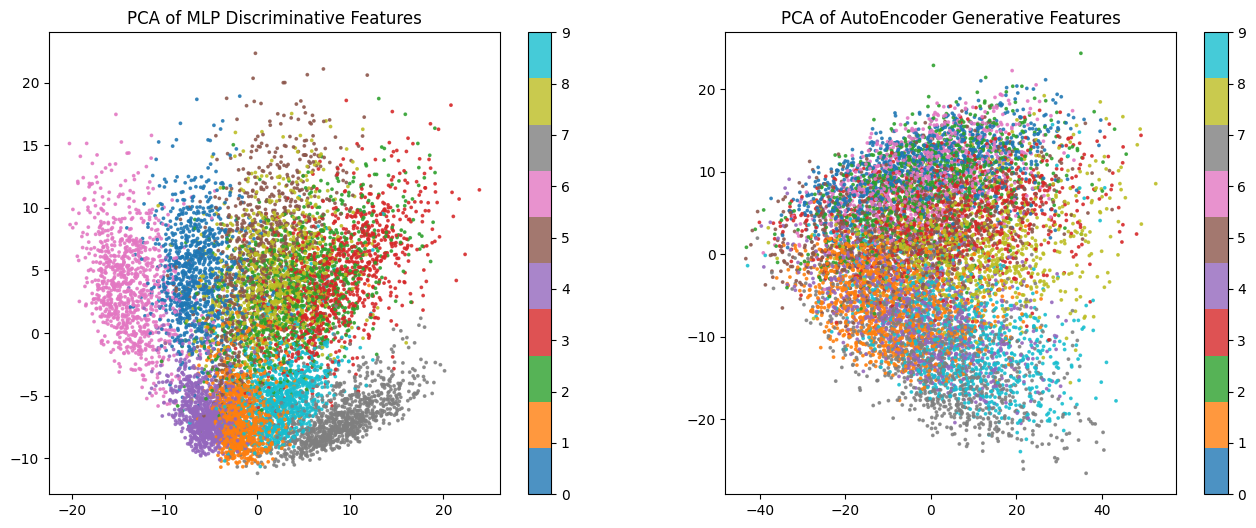

In [8]:
# --- 4. PCA Visualization ---
pca = PCA(n_components=2)
pca_mlp = pca.fit_transform(mlp_features_test)
pca_ae = pca.fit_transform(ae_features_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(pca_mlp[:, 0], pca_mlp[:, 1], c=Y_test_m, cmap='tab10', s=3, alpha=0.8)
axes[0].set_title('PCA of MLP Discriminative Features')
fig.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(pca_ae[:, 0], pca_ae[:, 1], c=Y_test_m, cmap='tab10', s=3, alpha=0.8)
axes[1].set_title('PCA of AutoEncoder Generative Features')
fig.colorbar(scatter2, ax=axes[1])

plt.show()

**Intuitive Explanation of Feature Differences:**

1. **MLP Features (Discriminative Representation):**
The objective of the MLP is strictly classification. Because it aims to minimize categorical cross-entropy, its hidden layers are forced to learn features that maximize the distance between different classes while ignoring intraclass variances (e.g., handwriting style or thickness) that don't help in separating digits. When visualized via PCA, you'll see dense, well-separated "islands" representing the 10 classes.

2. **AutoEncoder Features (Generative/Continuous Representation):**
The Autoencoder's objective is to perfectly reconstruct the input image. To minimize the Mean Squared Error (MSE), its bottleneck (latent space) must retain all the underlying structural details (stroke width, tilt angle, exact morphology). Digits with similar structural geometry (like 3 and 8, or 9 and 4) end up closer to each other. When mapped via PCA, the manifold looks much more continuous and mixed, representing a smooth transition of physical traits rather than hard classification boundaries.

## Part 4: Strided Convolution Binary
- Binary classifier for two MNIST classes.
- Reduce dimensions completely to 1x1 using strided convolutions.
- Use Dense layers exclusively where strictly necessary (none needed if flattened to scalar directly from 1x1 spatial dim).

In [9]:
# Filter dataset for binary classification (classes 0 and 1)
mask_train = (Y_train_m == 0) | (Y_train_m == 1)
mask_test = (Y_test_m == 0) | (Y_test_m == 1)

X_b_train = X_train_m[mask_train].reshape(-1, 28, 28, 1)
Y_b_train = Y_train_m[mask_train]
X_b_test = X_test_m[mask_test].reshape(-1, 28, 28, 1)
Y_b_test = Y_test_m[mask_test]

# Build CNN strictly using Conv2D layers with strides to reduce dimensionality
model_bin = Sequential()

# Input: 28x28 -> Strided Conv -> Output: 14x14
model_bin.add(Conv2D(8, (3, 3), strides=(2, 2), padding='same', activation='relu', input_shape=(28, 28, 1)))

# 14x14 -> Strided Conv -> Output: 7x7
model_bin.add(Conv2D(16, (3, 3), strides=(2, 2), padding='same', activation='relu'))

# 7x7 -> Strided Conv (padding valid) -> Output: 3x3
model_bin.add(Conv2D(32, (3, 3), strides=(2, 2), padding='valid', activation='relu'))

# 3x3 -> Conv (padding valid) -> Output: 1x1x1
model_bin.add(Conv2D(1, (3, 3), strides=(1, 1), padding='valid', activation='sigmoid'))

# Flatten the 1x1x1 tensor into a single scalar probability output (No dense layer needed)
model_bin.add(Flatten())

model_bin.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n--- Strided Convolutional Network Architecture ---")
model_bin.summary()

print("\nTraining Binary CNN using Strided Convolutions exclusively...")
model_bin.fit(X_b_train, Y_b_train, epochs=5, batch_size=32, validation_data=(X_b_test, Y_b_test), verbose=1)

test_loss_b, test_acc_b = model_bin.evaluate(X_b_test, Y_b_test, verbose=0)
print(f"\nBinary Classifier Test Accuracy: {test_acc_b:.4f}")


--- Strided Convolutional Network Architecture ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_165"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 1, 1, 1)        │           289 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_165 (Flatten)           │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,177 (24.13 KB)

 Trainable params: 6,177 (24.13 KB)

 Non-trainable params: 0 (0.00 B)


Training Binary CNN using Strided Convolutions exclusively...
Epoch 1/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9931 - loss: 0.0564 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 2/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9988 - loss: 0.0037 - val_accuracy: 0.9995 - val_loss: 0.0018
Epoch 3/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9994 - loss: 0.0021 - val_accuracy: 0.9991 - val_loss: 0.0014
Epoch 4/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9994 - loss: 0.0019 - val_accuracy: 0.9991 - val_loss: 0.0029
Epoch 5/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9994 - loss: 0.0019 - val_accuracy: 0.9995 - val_loss: 0.0011

Binary Classifier Test Accuracy: 0.9995


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Perceptrons as classifiers

**1. Perceptrons as classifiers**

In this task, we will reuse the data processing pipeline with Elliptical Fourier Descriptors, but the particular choice for the classifier will be a single perceptron, as presented in the lecture material.

**References**
* [About EFD](https://github.com/hbldh/pyefd)
* [Keras classification introduction](https://www.tensorflow.org/tutorials/keras/classification)
* [Used dataset](https://drive.google.com/drive/folders/1rPxI83BSdDqKNMjBXX1JRezk-DRYEI7M?usp=sharing)

In [ ]:
!pip install pyefd

In [ ]:
import cv2 as cv
import numpy as np
import os
from pyefd import elliptic_fourier_descriptors
from tqdm.notebook import tqdm

def load_dataset(dset_dir):
    image_index = {}

    class_list = os.listdir(dset_dir)

    for class_name in tqdm(class_list, desc="Classes"):
        in_cat_images = []
        cat_dir_path = f"{dset_dir}/{class_name}"

        file_list = os.listdir(cat_dir_path)

        for file_name in tqdm(file_list, desc=f"Loading {class_name}", leave=False):
            img_path = f"{cat_dir_path}/{file_name}"
            img = cv.imread(img_path, 0)

            if img is not None:
                in_cat_images.append(img)

        image_index[class_name] = in_cat_images

    return image_index


def extract_efd_feature(img):
  contours, _ = cv.findContours(img, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
  fd = []
  for cnt in contours:
    coeffs = elliptic_fourier_descriptors(np.squeeze(cnt), order=10, normalize=True)
    fd.append(coeffs.flatten()[3:])
  return np.array(fd)


def prepare_data(image_set):
  X = []
  Y = []
  for img_class, img_list in image_set.items():
    for image in img_list:
      try:
        fdesc = extract_efd_feature(image)
        X.append(np.max(fdesc, axis=0))
        Y.append(int(img_class))
      except Exception:
        continue # some corrupted images

  return np.array(X), np.array(Y)

In [ ]:
train_img = load_dataset("/content/drive/MyDrive/CAVA_2026/teaching/week9/MNIST_dataset/training")
val_img   = load_dataset("/content/drive/MyDrive/CAVA_2026/teaching/week9/MNIST_dataset/validation")
test_img  = load_dataset("/content/drive/MyDrive/CAVA_2026/teaching/week9/MNIST_dataset/testing")

X_train, Y_train = prepare_data(train_img)
X_val, Y_val = prepare_data(val_img)
X_test, Y_test = prepare_data(test_img)

Classes:   0%|          | 0/10 [00:00<?, ?it/s]

Loading 1:   0%|          | 0/126 [00:00<?, ?it/s]

Loading 3:   0%|          | 0/126 [00:00<?, ?it/s]

Loading 2:   0%|          | 0/126 [00:00<?, ?it/s]

Loading 5:   0%|          | 0/130 [00:00<?, ?it/s]

...

Loading 8:   0%|          | 0/20 [00:00<?, ?it/s]

Loading 6:   0%|          | 0/20 [00:00<?, ?it/s]

Loading 7:   0%|          | 0/20 [00:00<?, ?it/s]

Loading 9:   0%|          | 0/20 [00:00<?, ?it/s]

Loading 0:   0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
from keras.callbacks import Callback


class ValidationCallback(Callback):
  def __init__(self, train_data, validation_data, test_data, verbose=False):
    self.train_data = train_data
    self.validation_data = validation_data
    self.test_data = test_data
    self.train_log = {}
    self.val_log = {}
    self.test_log = {}
    self.verbose = verbose

  def on_epoch_end(self, epoch, logs={}):
    x_train, y_train = self.train_data
    x_val, y_val = self.validation_data
    x_test, y_test = self.test_data

    train_loss, train_acc = self.model.evaluate(x_train, y_train, verbose=0)
    val_loss, val_acc = self.model.evaluate(x_val, y_val, verbose=0)
    test_loss, test_acc = self.model.evaluate(x_test, y_test, verbose=0)

    self.train_log[epoch] = train_acc
    self.val_log[epoch] = val_acc
    self.test_log[epoch] = test_acc

    if self.verbose == True:
      log = 'E: {} - Train - Val - Test loss: {} - {} - {}, acc: {} - {} - {}'.format(
              epoch, train_loss, val_loss, test_loss, train_acc, val_acc, test_acc)
      print(log)

In [ ]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(10))
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

callbacks = [ValidationCallback((X_train, Y_train), (X_val, Y_val), (X_test, Y_test))]
model.fit(X_train, Y_train, epochs=60, callbacks=callbacks, verbose=0)

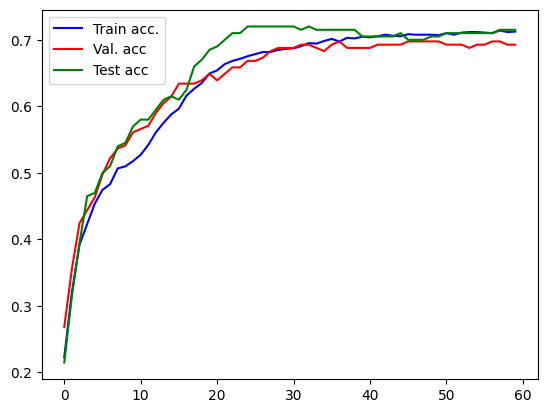

In [ ]:
import matplotlib.pyplot as plt

cb = callbacks[0]
plt.plot(list(cb.train_log.keys()), list(cb.train_log.values()), label='Train acc.', c='blue')
plt.plot(list(cb.val_log.keys()), list(cb.val_log.values()), label='Val. acc', c='red')
plt.plot(list(cb.test_log.keys()), list(cb.test_log.values()), label='Test acc', c='green')
plt.legend()

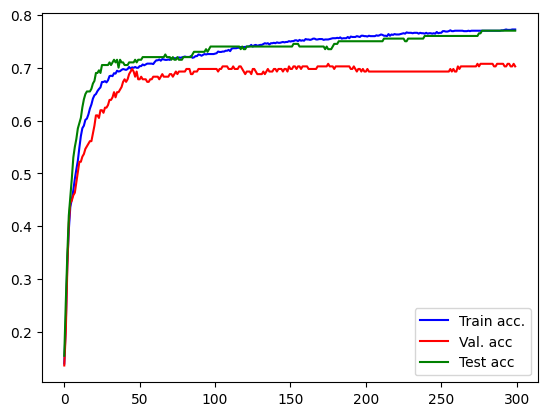

In [ ]:
# now, let's evaluate the behaviour of our model for after more epochs

model = Sequential()
model.add(Dense(10))
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


callbacks = [ValidationCallback((X_train, Y_train), (X_val, Y_val), (X_test, Y_test))]
model.fit(X_train, Y_train, epochs=300, callbacks=callbacks, verbose=0)

cb = callbacks[0]
plt.plot(list(cb.train_log.keys()), list(cb.train_log.values()), label='Train acc.', c='blue')
plt.plot(list(cb.val_log.keys()), list(cb.val_log.values()), label='Val. acc', c='red')
plt.plot(list(cb.test_log.keys()), list(cb.test_log.values()), label='Test acc', c='green')
plt.legend()

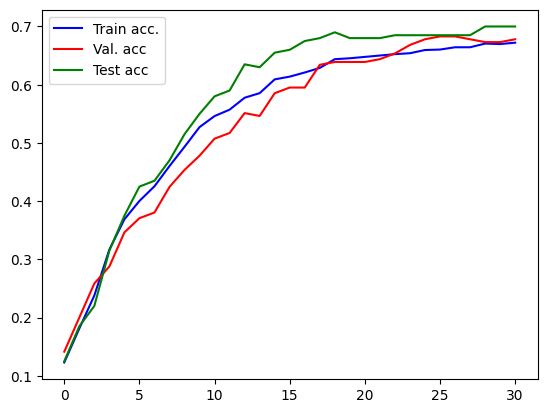

In [ ]:
# now, let's find the best number of epochs to train this model

model = Sequential()
model.add(Dense(10))
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


callbacks = [tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=5, verbose=0),
             ValidationCallback((X_train, Y_train), (X_val, Y_val), (X_test, Y_test))]
model.fit(X_train, Y_train, epochs=300, validation_data=(X_val, Y_val), callbacks=callbacks, verbose=0)

cb = callbacks[1]
plt.plot(list(cb.train_log.keys()), list(cb.train_log.values()), label='Train acc.', c='blue')
plt.plot(list(cb.val_log.keys()), list(cb.val_log.values()), label='Val. acc', c='red')
plt.plot(list(cb.test_log.keys()), list(cb.test_log.values()), label='Test acc', c='green')
plt.legend()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<Axes: >

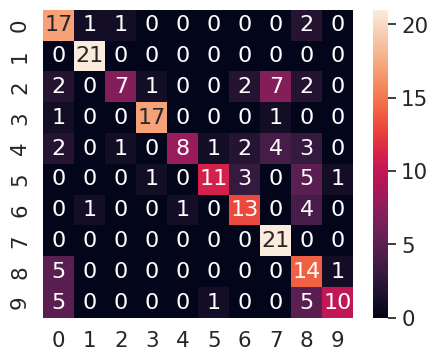

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sn
from sklearn.metrics import confusion_matrix

plt.rcParams['figure.figsize'] = [5, 4]
plt.rcParams['figure.dpi'] = 100

predict_x = model.predict(X_val)
predictions = np.argmax(predict_x, axis=1)

clf_confusion_matrix = confusion_matrix(Y_val, predictions)
classes = [str(i) for i in range(10)]
df_cmatrix = pd.DataFrame(clf_confusion_matrix, classes, classes)
sn.set(font_scale=1.4)
sn.heatmap(df_cmatrix, annot=True, annot_kws={"size": 16})

Epoch 1/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.0701 - loss: 2.3062 - val_accuracy: 0.0829 - val_loss: 2.2949
Epoch 2/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1261 - loss: 2.2837 - val_accuracy: 0.1561 - val_loss: 2.2744
Epoch 3/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1915 - loss: 2.2618 - val_accuracy: 0.2146 - val_loss: 2.2545
Epoch 4/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2419 - loss: 2.2406 - val_accuracy: 0.2537 - val_loss: 2.2349
Epoch 5/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2979 - loss: 2.2196 - val_accuracy: 0.3463 - val_loss: 2.2161
Epoch 6/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3452 - loss: 2.1993 - val_accuracy: 0.4000 - val_loss: 2.1973
Epoch 7/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3838 - loss: 2.1792 - val_accuracy: 0.4098 - val_loss: 2.1792
Epoch 8/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4192 - loss: 2.1598 - val_accuracy: 0.

<Axes: >

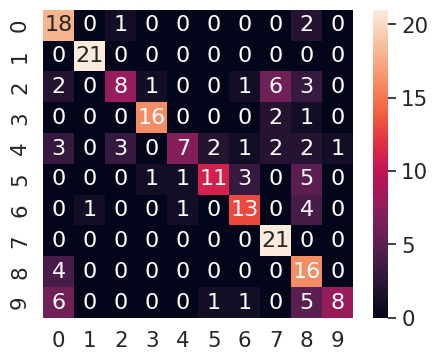

In [ ]:
# use the restore_best_params feature

model = Sequential()
model.add(Dense(10))
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                              restore_best_weights=True,
                                              patience=5, verbose=0),
             ValidationCallback((X_train, Y_train), (X_val, Y_val), (X_test, Y_test))]
model.fit(X_train, Y_train, epochs=300, validation_data=(X_val, Y_val), callbacks=callbacks, verbose=1)
predict_x = model.predict(X_val)
predictions = np.argmax(predict_x, axis=1)

clf_confusion_matrix = confusion_matrix(Y_val, predictions)
classes = [str(i) for i in range(10)]
df_cmatrix = pd.DataFrame(clf_confusion_matrix, classes, classes)
sn.set(font_scale=1.4)
sn.heatmap(df_cmatrix, annot=True, annot_kws={"size": 16})

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


<Axes: >

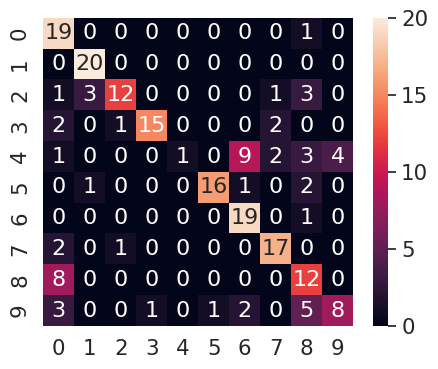

In [ ]:
# compute test split predictions and plot conf matrix
predict_x = model.predict(X_test)
predictions = np.argmax(predict_x, axis=1)

clf_confusion_matrix = confusion_matrix(Y_test, predictions)
classes = [str(i) for i in range(10)]
df_cmatrix = pd.DataFrame(clf_confusion_matrix, classes, classes)
sn.set(font_scale=1.4)
sn.heatmap(df_cmatrix, annot=True, annot_kws={"size": 16})

# 2. Feature extraction in MLP

In [ ]:
import tensorflow.keras.datasets as datasets
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten

(X_train, Y_train), (X_test, Y_test) = datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(X_train.shape) # 60000 28 x 28 images
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
# now, we will define a multi-layer perceptron for this task
# as the data is 2d, we will start by flattening it

layers = [64, 32, 16]

model = Sequential()
model.add(Flatten())

# now, let's add a sequence of Dense layers, based on ReLU activation
for sz in layers:
  model.add(Dense(sz, activation='relu'))

model.add(Dense(10)) # the definition of the classifier stage will be the same
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


# fit the model keeping 20% of the training data for validation
model.fit(X_train, Y_train, epochs=15, validation_split=0.2, verbose=1)
predict_x = model.predict(X_test)
predictions = np.argmax(predict_x, axis=1)

print("Classification accuracy: {}".format(accuracy_score(Y_test, predictions)))

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.2963 - loss: 2.0056 - val_accuracy: 0.4283 - val_loss: 1.5321
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5424 - loss: 1.2400 - val_accuracy: 0.6538 - val_loss: 0.9261
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7786 - loss: 0.6729 - val_accuracy: 0.9075 - val_loss: 0.4041
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9221 - loss: 0.3151 - val_accuracy: 0.9384 - val_loss: 0.2548
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9427 - loss: 0.2211 - val_accuracy: 0.9434 - val_loss: 0.2343
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9523 - loss: 0.1830 - val_accuracy: 0.9380 - val_loss: 0.2541
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9585 - loss: 0.1555 - val_accuracy: 0.9503 - val_loss: 0.2103
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9627 - loss: 0.1349 

<Axes: >

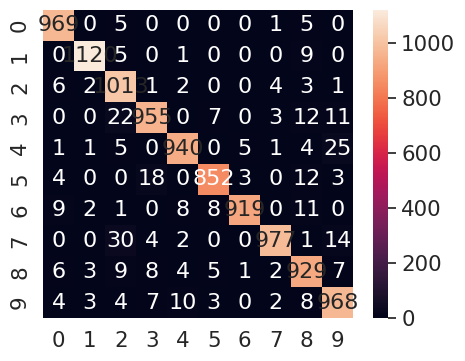

In [ ]:
clf_confusion_matrix = confusion_matrix(Y_test, predictions)
classes = [str(i) for i in range(10)]

df_cmatrix = pd.DataFrame(clf_confusion_matrix, classes, classes)
df_cmatrix.style.format("{:.1f}")


sn.set(font_scale=1.4)
sn.heatmap(df_cmatrix, annot=True, annot_kws={"size": 16}, fmt='g')

# 3. Regularization and overfitting

In [ ]:
# Firstly, we need a callback to observer the behaviour of the model on test data
# after a large number of epochs

from keras.callbacks import Callback


class TestCallback(Callback):
  def __init__(self, train_data, test_data, verbose=False):
    self.train_data = train_data
    self.test_data = test_data

    self.train_log = {}
    self.test_log = {}
    self.verbose = verbose

  def on_epoch_end(self, epoch, logs={}):
    x_train, y_train = self.train_data
    x_test, y_test = self.test_data

    train_loss, train_acc = self.model.evaluate(x_train, y_train, verbose=0)
    test_loss, test_acc = self.model.evaluate(x_test, y_test, verbose=0)

    self.train_log[epoch] = train_acc
    self.test_log[epoch] = test_acc

    if self.verbose == True:
      log = 'E: {} - Train - Test loss: {} - {}, acc: {} - {}'.format(
              epoch, train_loss, test_loss, train_acc, test_acc)
      print(log)

In [ ]:
layers = [64, 32, 16]

model = Sequential()
model.add(Flatten())

# now, let's add a sequence of Dense layers, based on ReLU activation
for sz in layers:
  model.add(Dense(sz, activation='relu'))

model.add(Dense(10)) # the definition of the classifier stage will be the same
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# use the callbacks to track the evolution
unreg_callbacks = [TestCallback((X_train, Y_train), (X_test, Y_test))]

# fit the model keeping 20% of the training data for validation
model.fit(X_train, Y_train, epochs=50, callbacks=unreg_callbacks, validation_split=0.2, verbose=1)
preds_x = model.predict(X_test, verbose=1)
predictions = np.argmax(preds_x, axis=1)

print("Classification accuracy: {}".format(accuracy_score(Y_test, predictions)))

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.1938 - loss: 2.2188 - val_accuracy: 0.2254 - val_loss: 2.0176
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3503 - loss: 1.7050 - val_accuracy: 0.4900 - val_loss: 1.3577
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5502 - loss: 1.1688 - val_accuracy: 0.6143 - val_loss: 1.0221
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7398 - loss: 0.7413 - val_accuracy: 0.8668 - val_loss: 0.5206
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9090 - loss: 0.3449 - val_accuracy: 0.9264 - val_loss: 0.2909
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9408 - loss: 0.2261 - val_accuracy: 0.9417 - val_loss: 0.2490
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9501 - loss: 0.1843 - val_accuracy: 0.9496 - val_loss: 0.2103
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9592 - loss: 0

In [ ]:
from tensorflow.keras import regularizers

layers = [64, 32, 16]
kern_regs = [4e-4, 2e-4, 1e-4]


model = Sequential()
model.add(Flatten())

# now, let's add a sequence of Dense layers, based on ReLU activation
for sz, penalty in zip(layers, kern_regs):
  model.add(Dense(sz, activation='relu', kernel_regularizer=regularizers.l2(penalty)))

model.add(Dense(10)) # the definition of the classifier stage will be the same
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# use the callbacks to track the evolution
l2_reg_callbacks = [TestCallback((X_train, Y_train), (X_test, Y_test))]

# fit the model keeping 20% of the training data for validation
model.fit(X_train, Y_train, epochs=50, callbacks=l2_reg_callbacks, validation_split=0.2, verbose=1)
preds_x = model.predict(X_test, verbose=1)
predictions = np.argmax(preds_x, axis=1)

print("Classification accuracy: {}".format(accuracy_score(Y_test, predictions)))

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.6252 - loss: 1.4512 - val_accuracy: 0.8177 - val_loss: 0.7568
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8676 - loss: 0.5484 - val_accuracy: 0.8898 - val_loss: 0.4556
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9176 - loss: 0.3576 - val_accuracy: 0.9323 - val_loss: 0.3077
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9366 - loss: 0.2814 - val_accuracy: 0.9293 - val_loss: 0.3179
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9457 - loss: 0.2427 - val_accuracy: 0.9487 - val_loss: 0.2412
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9535 - loss: 0.2100 - val_accuracy: 0.9522 - val_loss: 0.2261
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9591 - loss: 0.1895 - val_accuracy: 0.9595 - val_loss: 0.2019
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9632 - loss: 

In [ ]:
layers = [64, 32, 16]
kern_regs = [4e-4, 2e-4, 1e-4]


model = Sequential()
model.add(Flatten())

# now, let's add a sequence of Dense layers, based on ReLU activation
for sz, penalty in zip(layers, kern_regs):
  model.add(Dense(sz, activation='relu', kernel_regularizer=regularizers.l1(penalty)))

model.add(Dense(10)) # the definition of the classifier stage will be the same
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# use the callbacks to track the evolution
l1_reg_callbacks = [TestCallback((X_train, Y_train), (X_test, Y_test))]

# fit the model keeping 20% of the training data for validation
model.fit(X_train, Y_train, epochs=50, callbacks=l1_reg_callbacks, validation_split=0.2, verbose=1)
preds_x = model.predict(X_test, verbose=1)
predictions = np.argmax(preds_x, axis=1)

print("Classification accuracy: {}".format(accuracy_score(Y_test, predictions)))

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.7593 - loss: 1.8006 - val_accuracy: 0.8887 - val_loss: 0.9503
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9020 - loss: 0.8169 - val_accuracy: 0.9283 - val_loss: 0.6735
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9305 - loss: 0.6069 - val_accuracy: 0.9420 - val_loss: 0.5242
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9409 - loss: 0.5027 - val_accuracy: 0.9507 - val_loss: 0.4488
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9475 - loss: 0.4351 - val_accuracy: 0.9552 - val_loss: 0.4041
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9528 - loss: 0.3908 - val_accuracy: 0.9525 - val_loss: 0.3889
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9542 - loss: 0.3670 - val_accuracy: 0.9580 - val_loss: 0.3646
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9571 - loss: 

In [ ]:
from keras.layers import Dropout


layers = [64, 32, 16]
dropout_rate = [0.1, 0.05, 0.05]


model = Sequential()
model.add(Flatten())

# now, let's add a sequence of Dense layers, based on ReLU activation
for sz, dp_rate in zip(layers, dropout_rate):
  model.add(Dense(sz, activation='relu'))
  model.add(Dropout(rate=dp_rate))

model.add(Dense(10)) # the definition of the classifier stage will be the same
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# use the callbacks to track the evolution
dropout_reg_callbacks = [TestCallback((X_train, Y_train), (X_test, Y_test))]

# fit the model keeping 20% of the training data for validation
model.fit(X_train, Y_train, epochs=50, callbacks=dropout_reg_callbacks, validation_split=0.2, verbose=1)
preds_x = model.predict(X_test, verbose=1)
predictions = np.argmax(preds_x, axis=1)

print("Classification accuracy: {}".format(accuracy_score(Y_test, predictions)))

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.4665 - loss: 2.0704 - val_accuracy: 0.7204 - val_loss: 0.8978
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.7385 - loss: 0.8550 - val_accuracy: 0.8766 - val_loss: 0.5022
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.8372 - loss: 0.5469 - val_accuracy: 0.9262 - val_loss: 0.2890
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8753 - loss: 0.4236 - val_accuracy: 0.9337 - val_loss: 0.2700
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8991 - loss: 0.3578 - val_accuracy: 0.9400 - val_loss: 0.2277
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9158 - loss: 0.3094 - val_accuracy: 0.9418 - val_loss: 0.2215
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9253 - loss: 0.2699 - val_accuracy: 0.9458 - val_loss: 0.2080
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9329 - loss: 0.

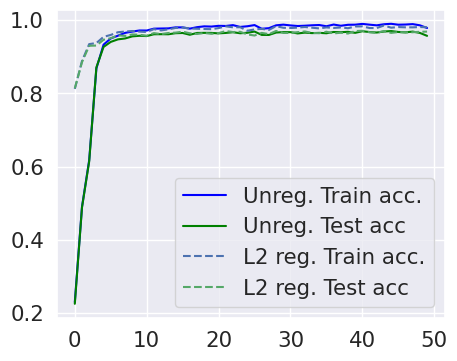

In [ ]:
cb = unreg_callbacks[0]
plt.plot(list(cb.train_log.keys()), list(cb.train_log.values()), label='Unreg. Train acc.', c='blue')
plt.plot(list(cb.test_log.keys()), list(cb.test_log.values()), label='Unreg. Test acc', c='green')

cb = l2_reg_callbacks[0]
plt.plot(list(cb.train_log.keys()), list(cb.train_log.values()), 'b--', label='L2 reg. Train acc.')
plt.plot(list(cb.test_log.keys()), list(cb.test_log.values()), 'g--', label='L2 reg. Test acc')
plt.legend()

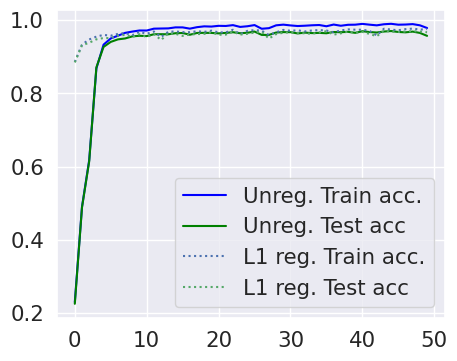

In [ ]:
cb = unreg_callbacks[0]
plt.plot(list(cb.train_log.keys()), list(cb.train_log.values()), label='Unreg. Train acc.', c='blue')
plt.plot(list(cb.test_log.keys()), list(cb.test_log.values()), label='Unreg. Test acc', c='green')

cb = l1_reg_callbacks[0]
plt.plot(list(cb.train_log.keys()), list(cb.train_log.values()), 'b:', label='L1 reg. Train acc.')
plt.plot(list(cb.test_log.keys()), list(cb.test_log.values()), 'g:', label='L1 reg. Test acc')
plt.legend()

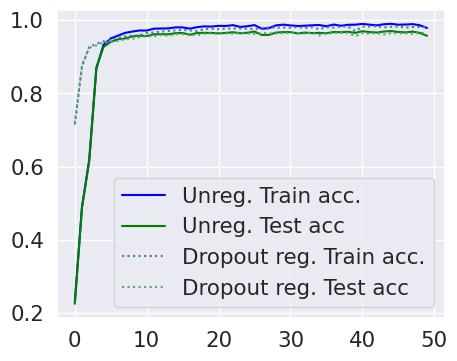

In [ ]:
cb = unreg_callbacks[0]
plt.plot(list(cb.train_log.keys()), list(cb.train_log.values()), label='Unreg. Train acc.', c='blue')
plt.plot(list(cb.test_log.keys()), list(cb.test_log.values()), label='Unreg. Test acc', c='green')

cb = dropout_reg_callbacks[0]
plt.plot(list(cb.train_log.keys()), list(cb.train_log.values()), 'b:', label='Dropout reg. Train acc.')
plt.plot(list(cb.test_log.keys()), list(cb.test_log.values()), 'g:', label='Dropout reg. Test acc')
plt.legend()

**4. AutoEncoders for image representation**

**References**
* [Keras documentation](https://blog.keras.io/building-autoencoders-in-keras.html)

In [ ]:
import keras
from keras import regularizers
from keras.layers import Dense

# same as the EFD descriptor
latent_dim = 37

input_flat = keras.Input(shape=(784, )) # 28 x 28
encoded = Dense(128, activation='relu')(input_flat)
encoded = Dense(64, activation='relu')(encoded)
latent = Dense(latent_dim, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(latent)
decoded = Dense(128, activation='relu')(decoded)
reconstruction = Dense(784, activation='relu')(decoded) # apply the logistic model

autoencoder = keras.Model(input_flat, reconstruction)
autoencoder.compile(optimizer='adam', loss='mse') # mse loss between input and output

In [ ]:
import numpy as np
from keras.datasets import mnist


(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [ ]:
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 0.0407 - val_loss: 0.0244
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0219 - val_loss: 0.0195
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0189 - val_loss: 0.0177
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0174 - val_loss: 0.0165
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0164 - val_loss: 0.0157
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0156 - val_loss: 0.0150
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0150 - val_loss: 0.0145
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0146 - val_loss: 0.0141
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0143 - val_loss: 0.0140
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0139 - val_loss: 0.0135
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0137 - val_loss: 0.0136
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# now build the graphs for the encoder
encoder  = keras.Model(input_flat, latent)
X_train = encoder.predict(x_train)
X_test = encoder.predict(x_test)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(60000, 37) (60000,)
(10000, 37) (10000,)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = SVC(C=1.5, kernel='rbf', gamma='auto')
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

print("Classification accuracy: {}".format(accuracy_score(y_test, predictions)))

Classification accuracy: 0.9771


<Axes: >

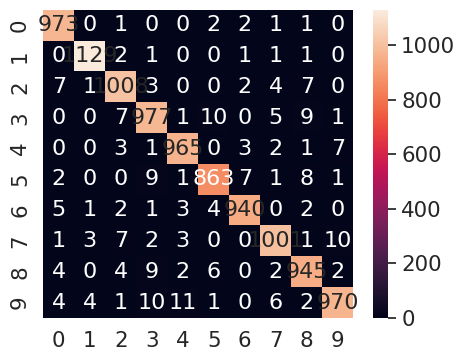

In [ ]:
clf_confusion_matrix = confusion_matrix(y_test, predictions)
classes = [str(i) for i in range(10)]

df_cmatrix = pd.DataFrame(clf_confusion_matrix, classes, classes)
df_cmatrix.style.format("{:.1f}")


sn.set(font_scale=1.4)
sn.heatmap(df_cmatrix, annot=True, annot_kws={"size": 16}, fmt='g')

# Convolutional Neural Nets for feature extraction

In this task, we will create our first CNN classifier. To compare it to the MLP classifier built last week, we will keep the same configuration, but the image will not be flattened as input. A sequence of Convolutional Layers will be used to extract features, and techniques for dimensionality reduction will be deployed.

**References**
* [Keras Conv Layer](https://keras.io/api/layers/convolution_layers/convolution2d/)
* [Keras CNN classifier](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html)

In [ ]:
from keras.datasets import mnist
from keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.utils import to_categorical
import pandas as pd
import seaborn as sn
import tensorflow as tf
from keras import regularizers
from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
from keras.callbacks import Callback


class TestCallback(Callback):
  def __init__(self, train_data, test_data, verbose=False):
    self.train_data = train_data
    self.test_data = test_data

    self.train_log = {}
    self.test_log = {}
    self.verbose = verbose

  def on_epoch_end(self, epoch, logs={}):
    x_train, y_train = self.train_data
    x_test, y_test = self.test_data

    train_loss, train_acc = self.model.evaluate(x_train, y_train, verbose=0)
    test_loss, test_acc = self.model.evaluate(x_test, y_test, verbose=0)

    self.train_log[epoch] = train_acc
    self.test_log[epoch] = test_acc

    if self.verbose == True:
      log = 'E: {} - Train - Test loss: {} - {}, acc: {} - {}'.format(
              epoch, train_loss, test_loss, train_acc, test_acc)
      print(log)

In [ ]:
# firslty, we will load the MNIST dataset
def get_mnist_data():
  (X_train, Y_train), (X_test, Y_test) = mnist.load_data()
  X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
  X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))
  Y_train = to_categorical(Y_train) # use one-hot encoding
  Y_test = to_categorical(Y_test)

  return X_train, Y_train, X_test, Y_test

X_train, Y_train, X_test, Y_test = get_mnist_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(10, activation='softmax')) # note the introduction of a softmax output layer, dropping from_logits=True
# compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
baseline_callbacks = [TestCallback((X_train, Y_train), (X_test, Y_test))]
model.fit(X_train, Y_train, epochs=20, callbacks=baseline_callbacks, validation_split=0.2)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 100s 64ms/step - accuracy: 0.4282 - loss: 3.2076 - val_accuracy: 0.4471 - val_loss: 1.4948
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.5017 - loss: 1.3511 - val_accuracy: 0.4453 - val_loss: 1.5108
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 61s 41ms/step - accuracy: 0.4971 - loss: 1.2612 - val_accuracy: 0.5304 - val_loss: 1.1334
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.5950 - loss: 1.0052 - val_accuracy: 0.5829 - val_loss: 0.9739
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 37ms/step - accuracy: 0.7135 - loss: 0.7667 - val_accuracy: 0.8015 - val_loss: 0.6221
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.8314 - loss: 0.5020 - val_accuracy: 0.8777 - val_loss: 0.3746
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.9162 - loss: 0.2912 - val_accuracy: 0.9416 - val_loss: 0.2278
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9472 

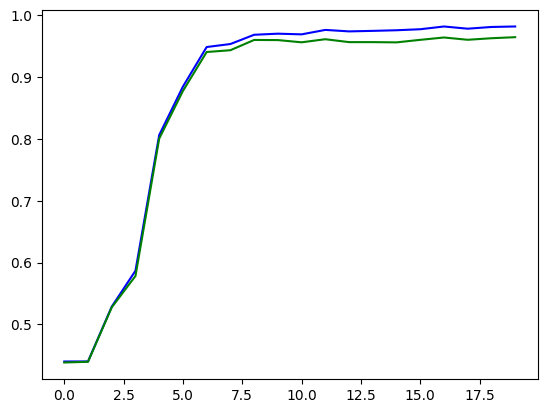

In [ ]:
import matplotlib.pyplot as plt

cb = baseline_callbacks[0]
plt.plot(list(cb.train_log.keys()), list(cb.train_log.values()), label='Train acc.', c='blue')
plt.plot(list(cb.test_log.keys()), list(cb.test_log.values()), label=' Test acc.', c='green')

In [ ]:
# now we will add complexity in the feature extraction stage, by stacking multiple layers
model = Sequential()
model.add(Conv2D(8, (3, 3), activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(16, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(10, activation='softmax')) # note the introduction of a softmax output layer, dropping from_logits=True
# compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

feature_callbacks = [TestCallback((X_train, Y_train), (X_test, Y_test))]
model.fit(X_train, Y_train, epochs=20, callbacks=feature_callbacks, validation_split=0.2)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.7887 - loss: 1.9982 - val_accuracy: 0.9103 - val_loss: 0.3642
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - accuracy: 0.9137 - loss: 0.3141 - val_accuracy: 0.9256 - val_loss: 0.2551
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9366 - loss: 0.2202 - val_accuracy: 0.9469 - val_loss: 0.1861
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9477 - loss: 0.1776 - val_accuracy: 0.9502 - val_loss: 0.1738
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 26ms/step - accuracy: 0.9572 - loss: 0.1461 - val_accuracy: 0.9566 - val_loss: 0.1552
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9601 - loss: 0.1347 - val_accuracy: 0.9622 - val_loss: 0.1319
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 26ms/step - accuracy: 0.9634 - loss: 0.1219 - val_accuracy: 0.9621 - val_loss: 0.1350
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9645 -

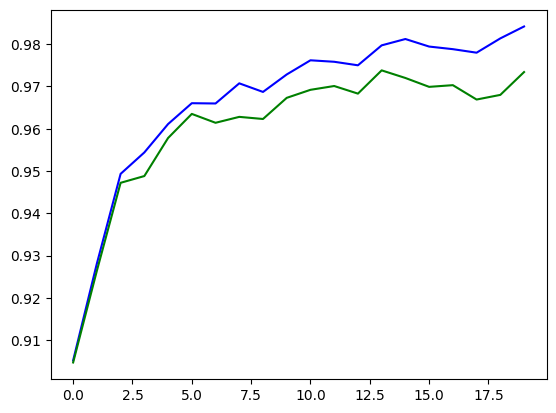

In [ ]:
cb = feature_callbacks[0]
plt.plot(list(cb.train_log.keys()), list(cb.train_log.values()), label='Train acc.', c='blue')
plt.plot(list(cb.test_log.keys()), list(cb.test_log.values()), label='Test acc', c='green')

In [ ]:
# Now, we will add complexity in the classifier stage
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(64, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(32, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(10, activation='softmax')) # note the introduction of a softmax output layer, dropping from_logits=True
# compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


clf_callbacks = [TestCallback((X_train, Y_train), (X_test, Y_test))]
model.fit(X_train, Y_train, epochs=20, callbacks=clf_callbacks, validation_split=0.2)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.8442 - loss: 5.8866 - val_accuracy: 0.9439 - val_loss: 0.6288
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9293 - loss: 0.5775 - val_accuracy: 0.9527 - val_loss: 0.3664
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - accuracy: 0.9495 - loss: 0.3044 - val_accuracy: 0.9613 - val_loss: 0.2107
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 79s 33ms/step - accuracy: 0.9595 - loss: 0.1832 - val_accuracy: 0.9431 - val_loss: 0.2913
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 59s 39ms/step - accuracy: 0.9646 - loss: 0.1447 - val_accuracy: 0.9517 - val_loss: 0.2124
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - accuracy: 0.9738 - loss: 0.1010 - val_accuracy: 0.9595 - val_loss: 0.1688
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9754 - loss: 0.0911 - val_accuracy: 0.9712 - val_loss: 0.1200
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - accuracy: 0.9797 -

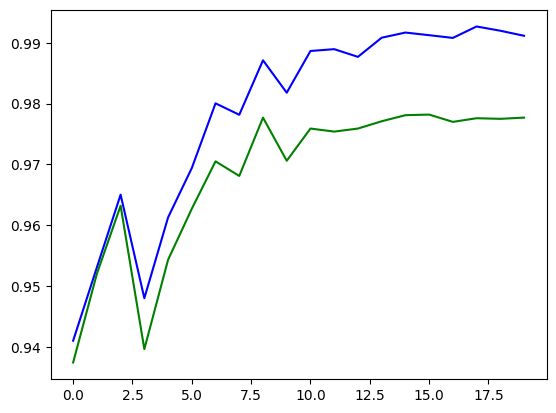

In [ ]:
cb = clf_callbacks[0]
plt.plot(list(cb.train_log.keys()), list(cb.train_log.values()), label='Train acc.', c='blue')
plt.plot(list(cb.test_log.keys()), list(cb.test_log.values()), label='Test acc', c='green')

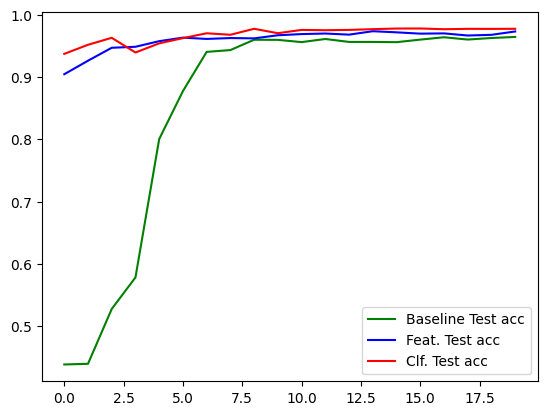

In [ ]:
plt.plot(list(baseline_callbacks[0].test_log.keys()), list(baseline_callbacks[0].test_log.values()), label='Baseline Test acc', c='g')
plt.plot(list(feature_callbacks[0].test_log.keys()), list(feature_callbacks[0].test_log.values()), label='Feat. Test acc', c='b')
plt.plot(list(clf_callbacks[0].test_log.keys()), list(clf_callbacks[0].test_log.values()), label='Clf. Test acc', c='r')
plt.legend()